APEXPLANET - TASK 3
DATA VISUALIZATION & DASHBOARDING

Project folder:
c:\Users\HP\OneDrive\Desktop\Task_1_EDA

Dataset found:
c:\Users\HP\OneDrive\Desktop\Task_1_EDA\notebooks\cleaned_dataset.csv

Original columns:
['#', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J']

Generic columns detected.
Real headers recovered successfully.

COLUMN DETECTION
Date                 : FOUND
Invoice_ID           : FOUND
City                 : FOUND
Customer_Type        : FOUND
Gender               : FOUND
Category             : FOUND
Product              : FOUND
Unit_Price           : FOUND
Quantity             : FOUND
Total_Sales          : FOUND

DATASET LOADED SUCCESSFULLY
Rows: 20
Columns: 11

Final columns:
['1', 'Date', 'Invoice_ID', 'City', 'Customer_Type', 'Gender', 'Category', 'Product', 'Unit_Price', 'Quantity', 'Total_Sales']

First 5 rows:


,1,Date,Invoice_ID,City,Customer_Type,Gender,Category,Product,Unit_Price,Quantity,Total_Sales
0,2,2026-01-02,A001,Mandalay,Member,Female,Food,Bread,120,2,240
1,3,2026-01-03,A002,Yangon,Normal,Male,Beverages,Coffee,250,3,750
2,4,2026-01-05,A003,Naypyitaw,Member,Female,Food,Cake,180,2,360
3,5,2026-01-07,A004,Mandalay,Normal,Female,Personal Care,Shampoo,320,1,320
4,6,2026-01-09,A005,Yangon,Member,Male,Food,Rice,90,5,450



BUSINESS INSIGHTS
Total Revenue       : 10470
Average Transaction : 523.5
Maximum Sale        : 900
Minimum Sale        : 240
Total Quantity      : 71
Total Transactions  : 20


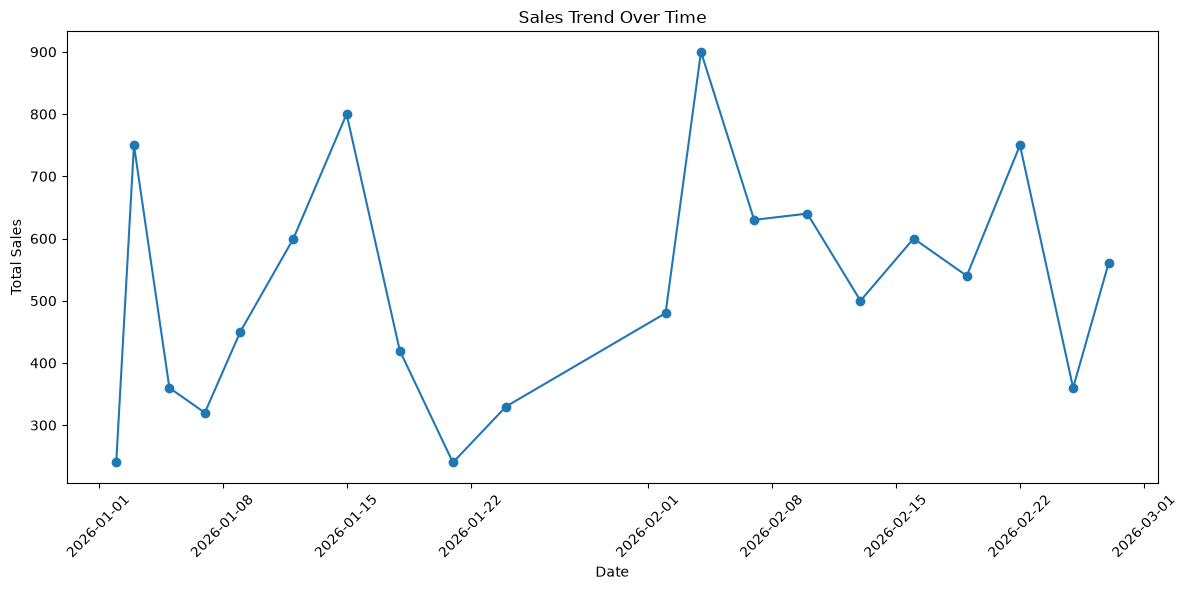

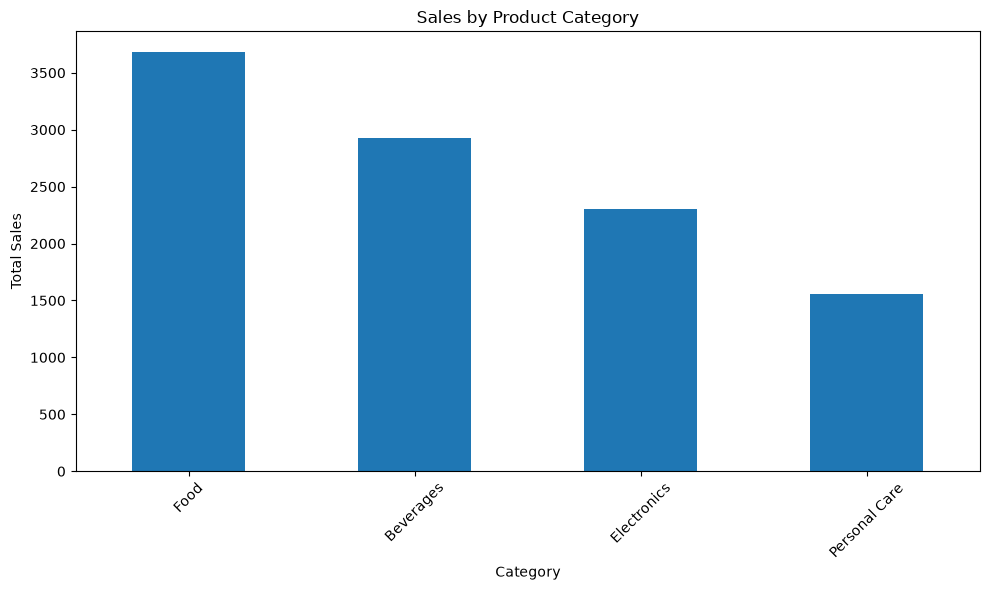

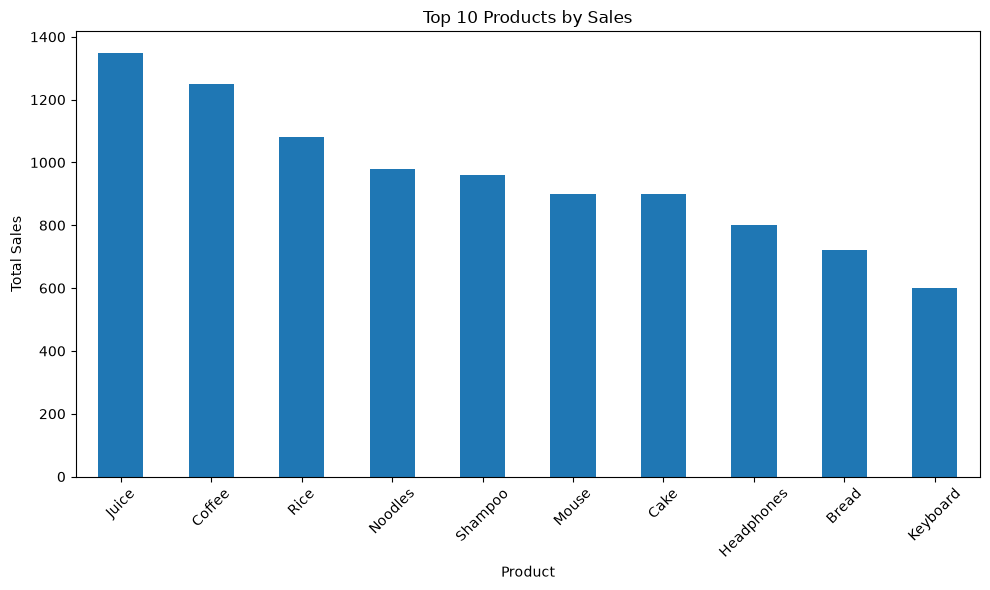

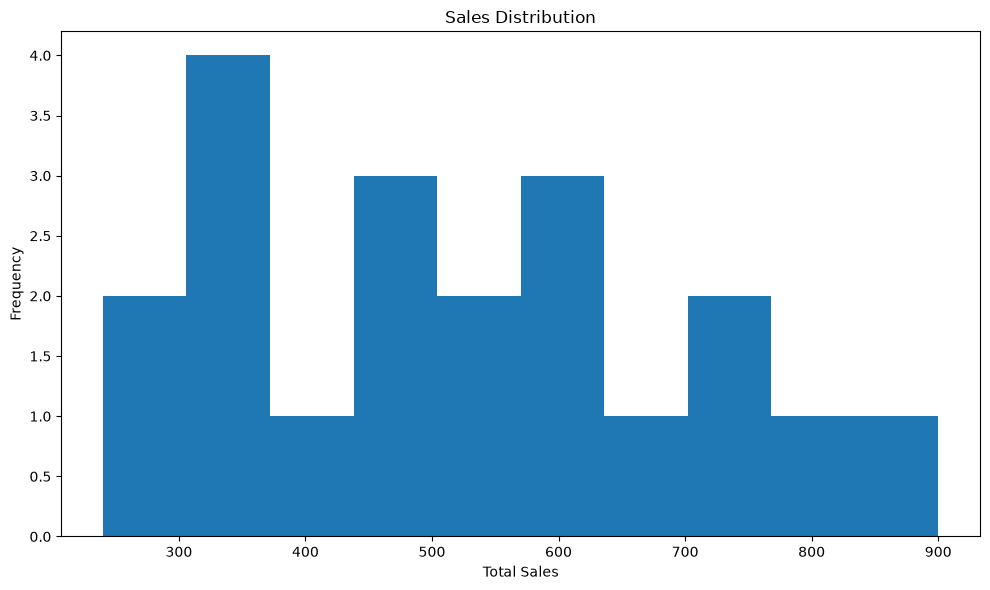

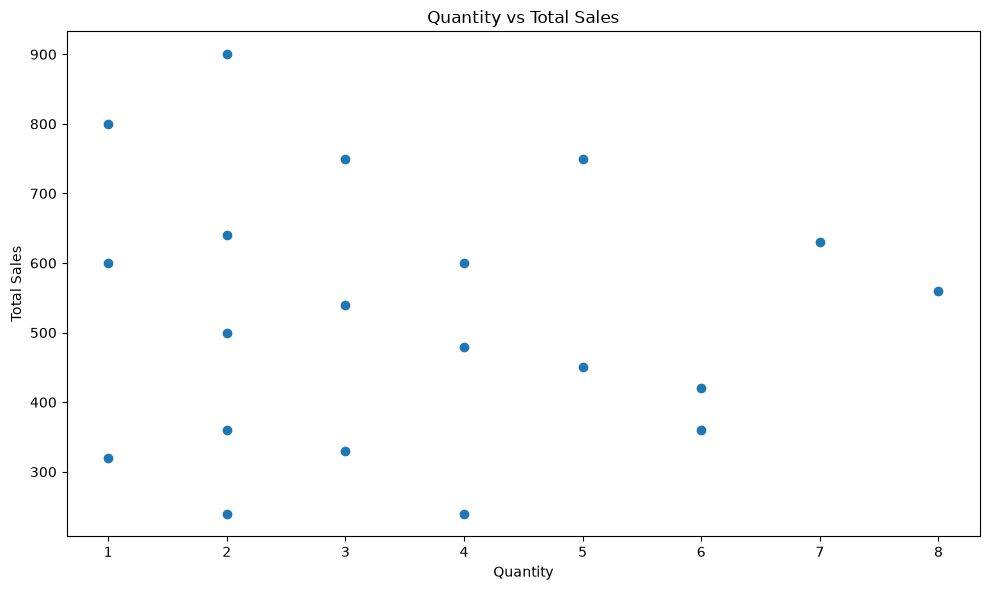

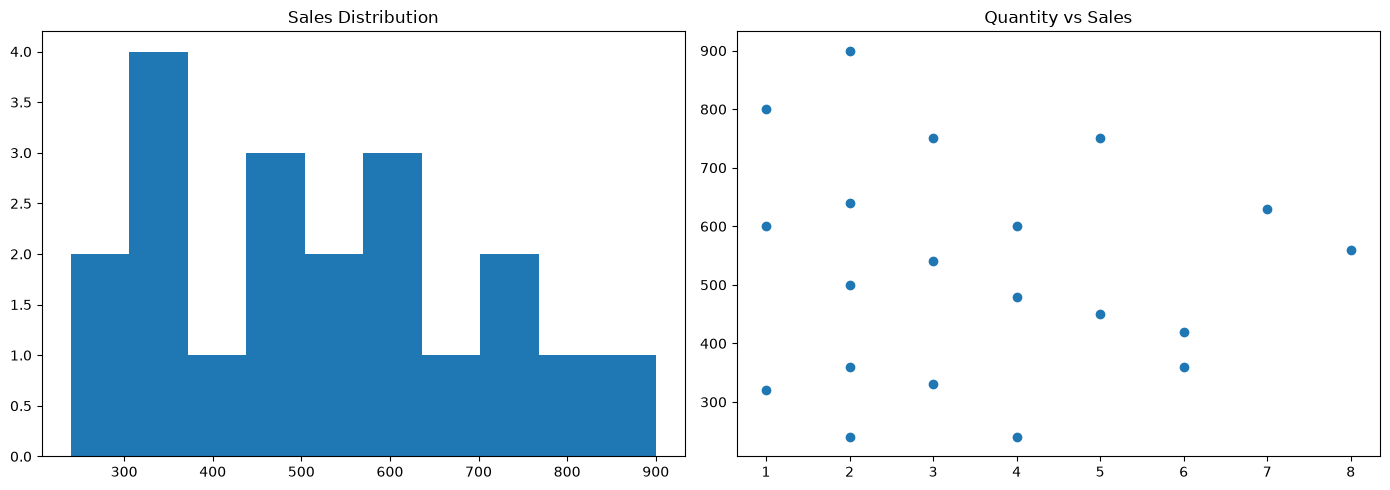

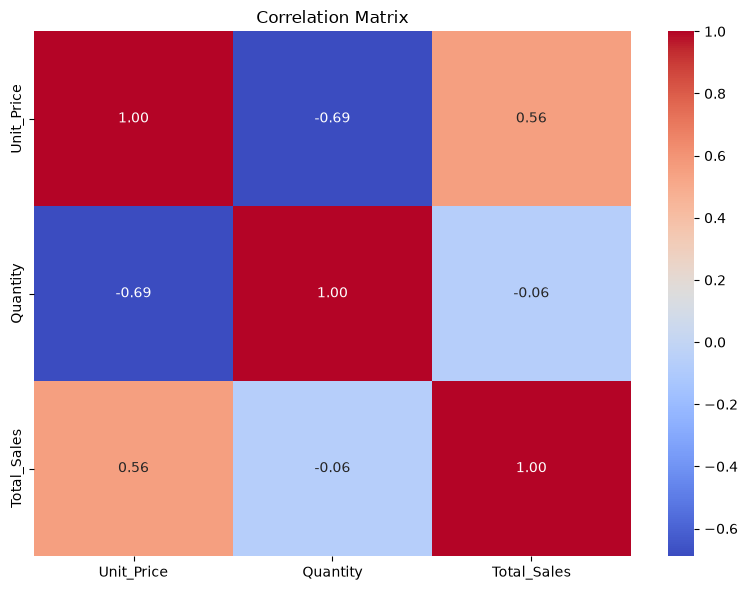

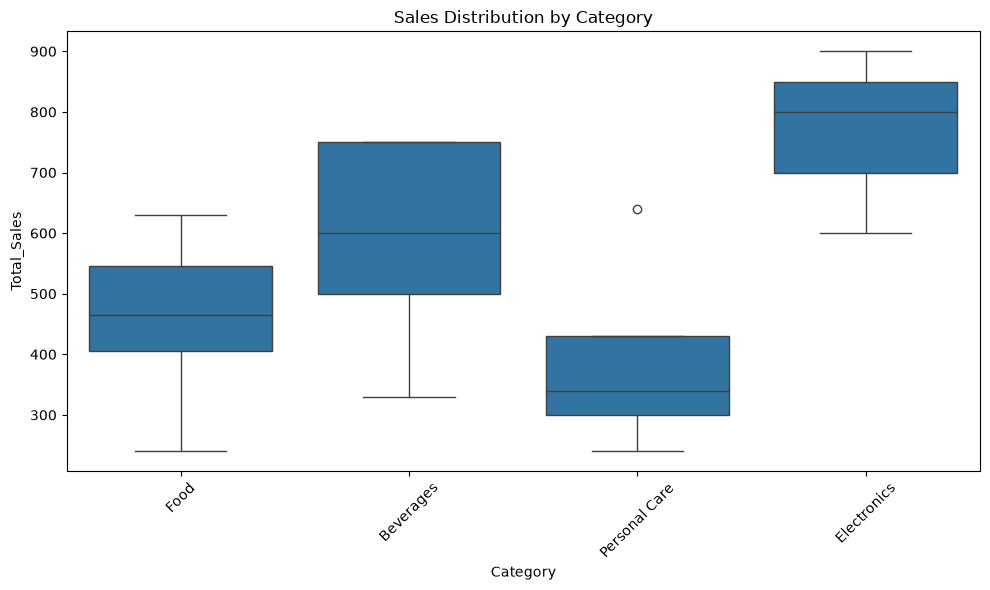

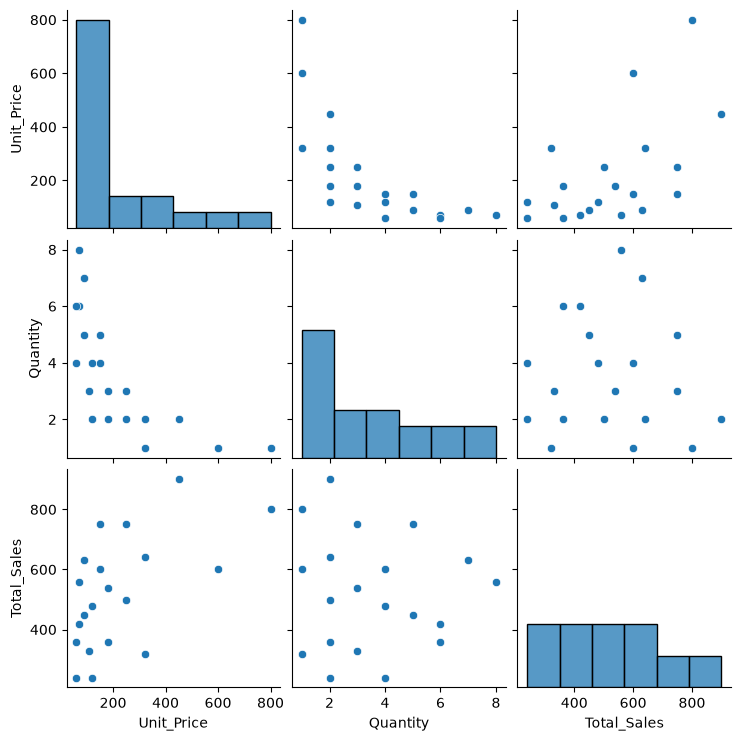

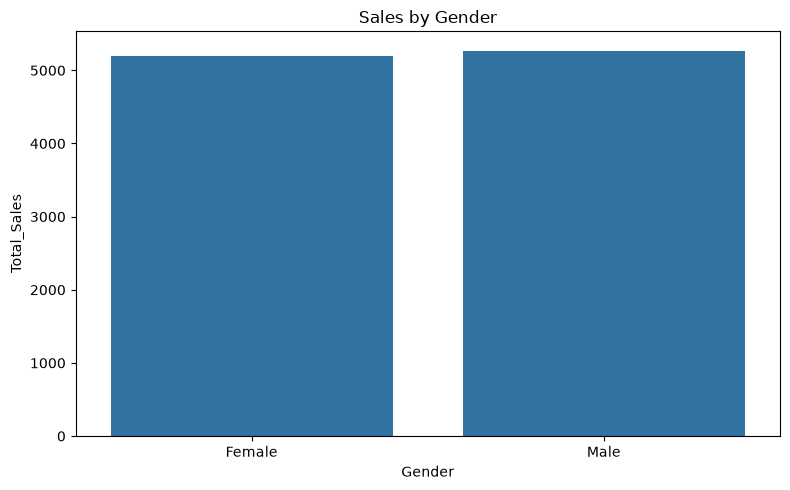

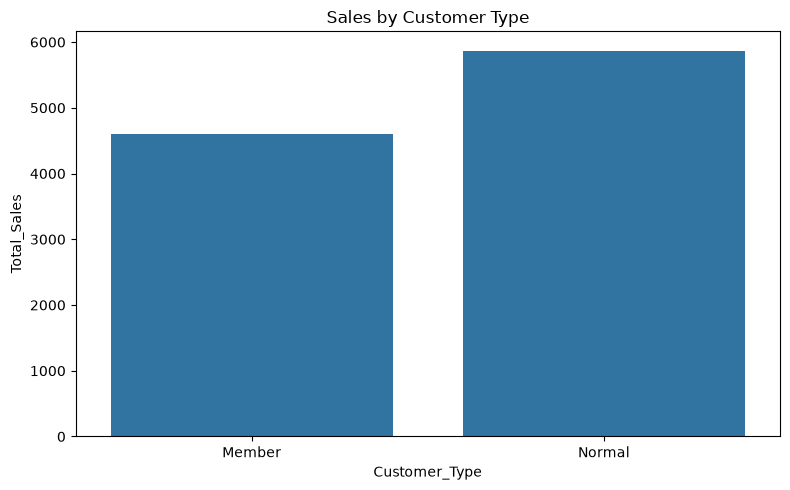

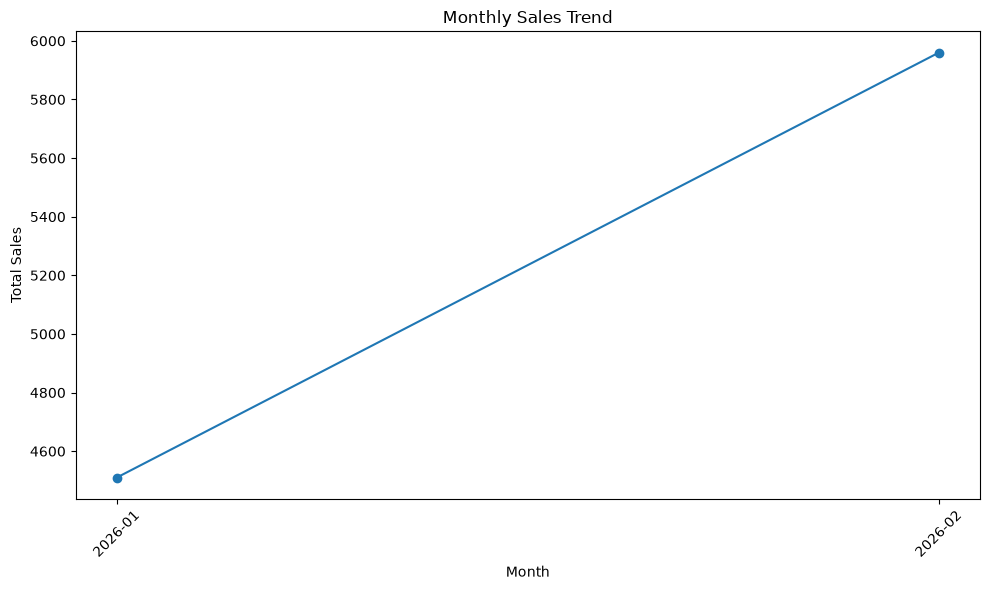

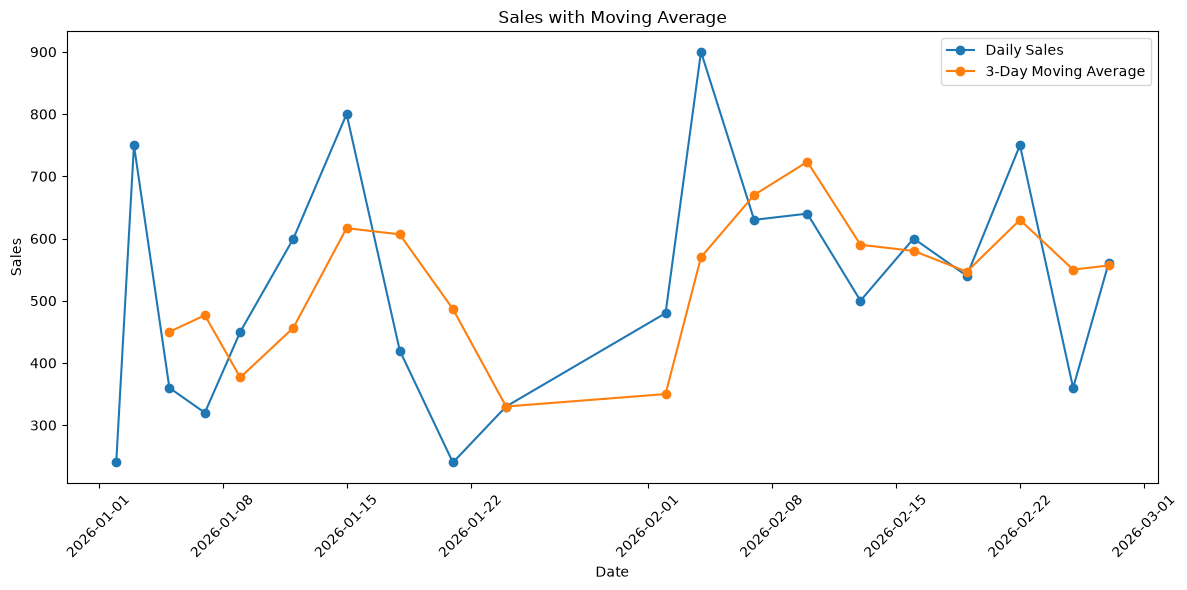

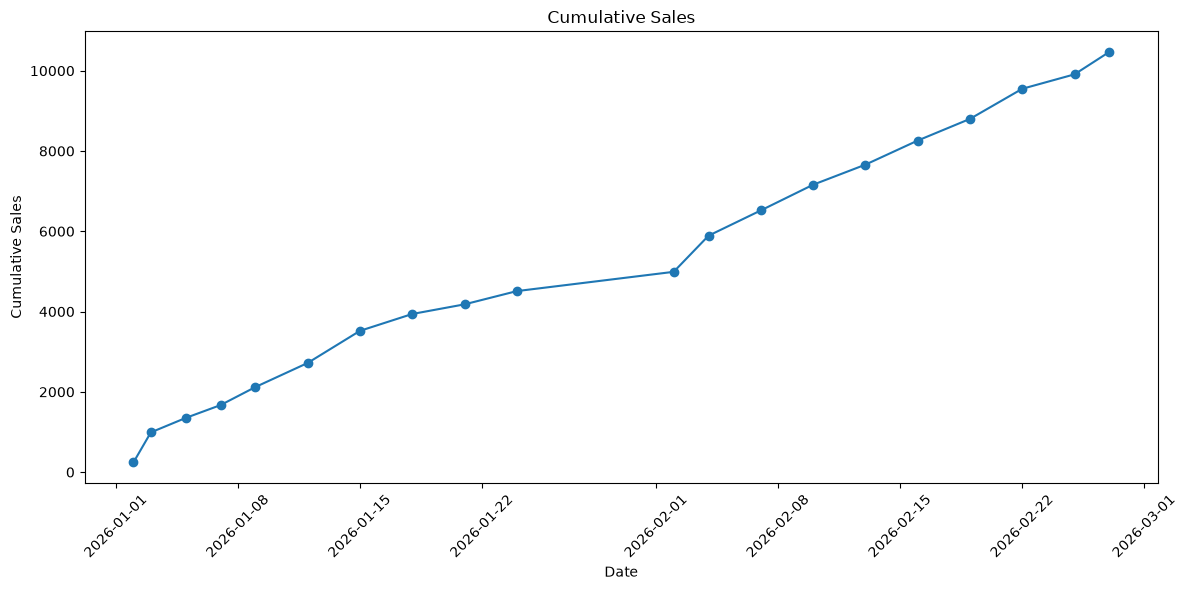


TASK 3 SUMMARY


,Metric,Value
0,Total Revenue,10470.0
1,Average Transaction,523.5
2,Maximum Sale,900.0
3,Minimum Sale,240.0
4,Total Transactions,20.0
5,Total Quantity,71.0



TASK 3 COMPLETED SUCCESSFULLY!

Files created:
1. c:\Users\HP\OneDrive\Desktop\Task_1_EDA\data\cleaned\task3_cleaned_dataset.csv
2. c:\Users\HP\OneDrive\Desktop\Task_1_EDA\reports\task3_summary.csv
3. c:\Users\HP\OneDrive\Desktop\Task_1_EDA\reports\task3_visualizations

Interactive HTML charts saved successfully.

PYTHON VISUALIZATION PART COMPLETE


In [ ]:
# ============================================================
# APEXPLANET - TASK 3
# DATA VISUALIZATION & DASHBOARDING
# COMPLETE ERROR-SAFE VERSION
# ============================================================

import pandas as  pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

print("=" * 70)
print("APEXPLANET - TASK 3")
print("DATA VISUALIZATION & DASHBOARDING")
print("=" * 70)


# ============================================================
# 1. PROJECT PATH
# ============================================================

CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name.lower() == "notebooks":
    PROJECT_DIR = CURRENT_DIR.parent
else:
    PROJECT_DIR = CURRENT_DIR

print("\nProject folder:")
print(PROJECT_DIR)


# ============================================================
# 2. FIND DATASET
# ============================================================

possible_files = [
    PROJECT_DIR / "notebooks" / "cleaned_dataset.csv",
    PROJECT_DIR / "data" / "cleaned" / "sales.csv",
    PROJECT_DIR / "data" / "raw" / "sales.csv",
    PROJECT_DIR / "cleaned_dataset.csv",
    PROJECT_DIR / "sales.csv"
]

DATA_FILE = None

for file in possible_files:
    if file.exists():
        DATA_FILE = file
        break

if DATA_FILE is None:
    raise FileNotFoundError(
        "Dataset not found. Please check cleaned_dataset.csv."
    )

print("\nDataset found:")
print(DATA_FILE)


# ============================================================
# 3. LOAD DATA
# ============================================================

df = pd.read_csv(DATA_FILE)

print("\nOriginal columns:")
print(df.columns.tolist())


# ============================================================
# 4. FIX A, B, C... COLUMN PROBLEM
# ============================================================

generic_names = [
    "#", "A", "B", "C", "D",
    "E", "F", "G", "H", "I", "J"
]

if list(df.columns) == generic_names:

    print("\nGeneric columns detected.")

    # First row contains actual headers
    real_headers = (
        df.iloc[0]
        .astype(str)
        .str.strip()
        .tolist()
    )

    # Remove header row from data
    df = df.iloc[1:].copy()

    # Apply real headers
    df.columns = real_headers

    print("Real headers recovered successfully.")


# ============================================================
# 5. CLEAN COLUMN NAMES
# ============================================================

df.columns = [
    str(col)
    .strip()
    .replace(" ", "_")
    .replace("-", "_")
    for col in df.columns
]


# ============================================================
# 6. STANDARDIZE COLUMN NAMES
# ============================================================

rename_map = {}

for col in df.columns:

    c = col.lower().strip()

    if c in ["date", "order_date", "sales_date"]:
        rename_map[col] = "Date"

    elif c in [
        "invoice_id",
        "invoice",
        "transaction_id"
    ]:
        rename_map[col] = "Invoice_ID"

    elif c in ["city", "location"]:
        rename_map[col] = "City"

    elif c in [
        "customer_type",
        "customer_segment"
    ]:
        rename_map[col] = "Customer_Type"

    elif c == "gender":
        rename_map[col] = "Gender"

    elif c in [
        "category",
        "product_category"
    ]:
        rename_map[col] = "Category"

    elif c in [
        "product",
        "product_name"
    ]:
        rename_map[col] = "Product"

    elif c in [
        "unit_price",
        "price",
        "unitprice"
    ]:
        rename_map[col] = "Unit_Price"

    elif c in [
        "quantity",
        "qty",
        "units"
    ]:
        rename_map[col] = "Quantity"

    elif c in [
        "total_sales",
        "sales",
        "revenue",
        "total_revenue"
    ]:
        rename_map[col] = "Total_Sales"


df.rename(columns=rename_map, inplace=True)


# ============================================================
# 7. CHECK REQUIRED COLUMNS
# ============================================================

print("\n" + "=" * 70)
print("COLUMN DETECTION")
print("=" * 70)

required_columns = [
    "Date",
    "Invoice_ID",
    "City",
    "Customer_Type",
    "Gender",
    "Category",
    "Product",
    "Unit_Price",
    "Quantity",
    "Total_Sales"
]

for col in required_columns:

    if col in df.columns:
        print(f"{col:20} : FOUND")

    else:
        print(f"{col:20} : NOT FOUND")


# ============================================================
# 8. CONVERT DATA TYPES
# ============================================================

if "Date" in df.columns:

    df["Date"] = pd.to_datetime(
        df["Date"],
        errors="coerce"
    )

if "Unit_Price" in df.columns:

    df["Unit_Price"] = pd.to_numeric(
        df["Unit_Price"],
        errors="coerce"
    )

if "Quantity" in df.columns:

    df["Quantity"] = pd.to_numeric(
        df["Quantity"],
        errors="coerce"
    )

if "Total_Sales" in df.columns:

    df["Total_Sales"] = pd.to_numeric(
        df["Total_Sales"],
        errors="coerce"
    )


# ============================================================
# 9. CREATE TOTAL SALES IF NEEDED
# ============================================================

if (
    "Total_Sales" not in df.columns
    and
    "Unit_Price" in df.columns
    and
    "Quantity" in df.columns
):

    df["Total_Sales"] = (
        df["Unit_Price"] *
        df["Quantity"]
    )


# ============================================================
# 10. REMOVE INVALID ROWS
# ============================================================

df = df.dropna(
    subset=["Total_Sales"]
).copy()

df.reset_index(
    drop=True,
    inplace=True
)


# ============================================================
# 11. SUCCESS MESSAGE
# ============================================================

print("\n" + "=" * 70)
print("DATASET LOADED SUCCESSFULLY")
print("=" * 70)

print("Rows:", len(df))
print("Columns:", len(df.columns))

print("\nFinal columns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())


# ============================================================
# 12. BASIC BUSINESS INSIGHTS
# ============================================================

total_sales = df["Total_Sales"].sum()
average_sales = df["Total_Sales"].mean()
maximum_sales = df["Total_Sales"].max()
minimum_sales = df["Total_Sales"].min()

print("\n" + "=" * 70)
print("BUSINESS INSIGHTS")
print("=" * 70)

print("Total Revenue       :", round(total_sales, 2))
print("Average Transaction :", round(average_sales, 2))
print("Maximum Sale        :", round(maximum_sales, 2))
print("Minimum Sale        :", round(minimum_sales, 2))

if "Quantity" in df.columns:
    print("Total Quantity      :", df["Quantity"].sum())

print("Total Transactions  :", len(df))


# ============================================================
# 13. LINE PLOT - SALES TREND
# ============================================================

if "Date" in df.columns:

    daily_sales = (
        df.groupby("Date")["Total_Sales"]
        .sum()
        .reset_index()
        .sort_values("Date")
    )

    plt.figure(figsize=(12, 6))

    plt.plot(
        daily_sales["Date"],
        daily_sales["Total_Sales"],
        marker="o"
    )

    plt.title("Sales Trend Over Time")
    plt.xlabel("Date")
    plt.ylabel("Total Sales")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


# ============================================================
# 14. BAR CHART - CATEGORY
# ============================================================

if "Category" in df.columns:

    category_sales = (
        df.groupby("Category")["Total_Sales"]
        .sum()
        .sort_values(ascending=False)
    )

    plt.figure(figsize=(10, 6))

    category_sales.plot(
        kind="bar"
    )

    plt.title("Sales by Product Category")
    plt.xlabel("Category")
    plt.ylabel("Total Sales")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


# ============================================================
# 15. TOP 10 PRODUCTS
# ============================================================

if "Product" in df.columns:

    product_sales = (
        df.groupby("Product")["Total_Sales"]
        .sum()
        .sort_values(ascending=False)
        .head(10)
    )

    plt.figure(figsize=(10, 6))

    product_sales.plot(
        kind="bar"
    )

    plt.title("Top 10 Products by Sales")
    plt.xlabel("Product")
    plt.ylabel("Total Sales")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


# ============================================================
# 16. HISTOGRAM
# ============================================================

plt.figure(figsize=(10, 6))

plt.hist(
    df["Total_Sales"],
    bins=10
)

plt.title("Sales Distribution")
plt.xlabel("Total Sales")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


# ============================================================
# 17. SCATTER PLOT
# ============================================================

if "Quantity" in df.columns:

    plt.figure(figsize=(10, 6))

    plt.scatter(
        df["Quantity"],
        df["Total_Sales"]
    )

    plt.title("Quantity vs Total Sales")
    plt.xlabel("Quantity")
    plt.ylabel("Total Sales")

    plt.tight_layout()
    plt.show()


# ============================================================
# 18. SUBPLOTS
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

axes[0].hist(
    df["Total_Sales"],
    bins=10
)

axes[0].set_title(
    "Sales Distribution"
)

if "Quantity" in df.columns:

    axes[1].scatter(
        df["Quantity"],
        df["Total_Sales"]
    )

    axes[1].set_title(
        "Quantity vs Sales"
    )

plt.tight_layout()
plt.show()


# ============================================================
# 19. SEABORN HEATMAP
# ============================================================

numeric_columns = [
    col
    for col in [
        "Unit_Price",
        "Quantity",
        "Total_Sales"
    ]
    if col in df.columns
]

if len(numeric_columns) >= 2:

    plt.figure(figsize=(8, 6))

    sns.heatmap(
        df[numeric_columns].corr(),
        annot=True,
        fmt=".2f",
        cmap="coolwarm"
    )

    plt.title(
        "Correlation Matrix"
    )

    plt.tight_layout()
    plt.show()


# ============================================================
# 20. SEABORN BOXPLOT
# ============================================================

if "Category" in df.columns:

    plt.figure(figsize=(10, 6))

    sns.boxplot(
        data=df,
        x="Category",
        y="Total_Sales"
    )

    plt.title(
        "Sales Distribution by Category"
    )

    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()


# ============================================================
# 21. SEABORN PAIRPLOT
# ============================================================

pair_columns = [
    col
    for col in [
        "Unit_Price",
        "Quantity",
        "Total_Sales"
    ]
    if col in df.columns
]

if len(pair_columns) >= 2:

    sns.pairplot(
        df[pair_columns]
    )

    plt.show()


# ============================================================
# 22. GENDER SALES
# ============================================================

if "Gender" in df.columns:

    gender_sales = (
        df.groupby("Gender")["Total_Sales"]
        .sum()
        .reset_index()
    )

    plt.figure(figsize=(8, 5))

    sns.barplot(
        data=gender_sales,
        x="Gender",
        y="Total_Sales"
    )

    plt.title(
        "Sales by Gender"
    )

    plt.tight_layout()
    plt.show()


# ============================================================
# 23. CUSTOMER TYPE SALES
# ============================================================

if "Customer_Type" in df.columns:

    customer_sales = (
        df.groupby("Customer_Type")["Total_Sales"]
        .sum()
        .reset_index()
    )

    plt.figure(figsize=(8, 5))

    sns.barplot(
        data=customer_sales,
        x="Customer_Type",
        y="Total_Sales"
    )

    plt.title(
        "Sales by Customer Type"
    )

    plt.tight_layout()
    plt.show()


# ============================================================
# 24. MONTHLY SALES
# ============================================================

if "Date" in df.columns:

    df["Month"] = (
        df["Date"]
        .dt.to_period("M")
        .astype(str)
    )

    monthly_sales = (
        df.groupby("Month")["Total_Sales"]
        .sum()
        .reset_index()
    )

    plt.figure(figsize=(10, 6))

    plt.plot(
        monthly_sales["Month"],
        monthly_sales["Total_Sales"],
        marker="o"
    )

    plt.title(
        "Monthly Sales Trend"
    )

    plt.xlabel("Month")
    plt.ylabel("Total Sales")

    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()


# ============================================================
# 25. MOVING AVERAGE
# ============================================================

if "Date" in df.columns:

    daily_sales = (
        df.groupby("Date")["Total_Sales"]
        .sum()
        .reset_index()
        .sort_values("Date")
    )

    daily_sales["Moving_Average"] = (
        daily_sales["Total_Sales"]
        .rolling(window=3)
        .mean()
    )

    plt.figure(figsize=(12, 6))

    plt.plot(
        daily_sales["Date"],
        daily_sales["Total_Sales"],
        marker="o",
        label="Daily Sales"
    )

    plt.plot(
        daily_sales["Date"],
        daily_sales["Moving_Average"],
        marker="o",
        label="3-Day Moving Average"
    )

    plt.title(
        "Sales with Moving Average"
    )

    plt.xlabel("Date")
    plt.ylabel("Sales")

    plt.legend()

    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()


# ============================================================
# 26. CUMULATIVE SALES
# ============================================================

if "Date" in  df.columns:

    daily_sales["Cumulative_Sales"] = (
        daily_sales["Total_Sales"]
        .cumsum()
    )

    plt.figure(figsize=(12, 6))

    plt.plot(
        daily_sales["Date"],
        daily_sales["Cumulative_Sales"],
        marker="o"
    )

    plt.title(
        "Cumulative Sales"
    )

    plt.xlabel("Date")
    plt.ylabel("Cumulative Sales")

    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()


# ============================================================
# 27. PLOTLY INTERACTIVE BAR
# IMPORTANT:
# We use write_html(), NOT fig.show()
# This avoids the nbformat error.
# ============================================================

interactive_dir = (
    PROJECT_DIR /
    "reports" /
    "task3_visualizations"
)

interactive_dir.mkdir(
    parents=True,
    exist_ok=True
)


if "Category" in df.columns:

    category_data = (
        df.groupby("Category")["Total_Sales"]
        .sum()
        .reset_index()
    )

    fig = px.bar(
        category_data,
        x="Category",
        y="Total_Sales",
        title="Interactive Category Sales"
    )

    fig.write_html(
        interactive_dir /
        "interactive_category_sales.html"
    )


# ============================================================
# 28. PLOTLY INTERACTIVE PRODUCT CHART
# ============================================================

if "Product" in df.columns:

    product_data = (
        df.groupby("Product")
        .agg(
            Total_Sales=("Total_Sales", "sum"),
            Quantity=("Quantity", "sum")
        )
        .reset_index()
        .sort_values(
            "Total_Sales",
            ascending=False
        )
    )

    fig = px.bar(
        product_data,
        x="Product",
        y="Total_Sales",
        hover_data=["Quantity"],
        title="Interactive Product Sales"
    )

    fig.write_html(
        interactive_dir /
        "interactive_product_sales.html"
    )


# ============================================================
# 29. PLOTLY INTERACTIVE LINE CHART
# ============================================================

if "Date" in df.columns:

    fig = px.line(
        daily_sales,
        x="Date",
        y="Total_Sales",
        markers=True,
        title="Interactive Daily Sales"
    )

    fig.write_html(
        interactive_dir /
        "interactive_daily_sales.html"
    )


# ============================================================
# 30. PLOTLY INTERACTIVE SCATTER
# ============================================================

if "Quantity" in df.columns:

    fig = px.scatter(
        df,
        x="Quantity",
        y="Total_Sales",
        hover_data=df.columns.tolist(),
        title="Interactive Quantity vs Sales"
    )

    fig.write_html(
        interactive_dir /
        "interactive_quantity_sales.html"
    )


# ============================================================
# 31. CREATE SUMMARY TABLE
# ============================================================

summary = pd.DataFrame({
    "Metric": [
        "Total Revenue",
        "Average Transaction",
        "Maximum Sale",
        "Minimum Sale",
        "Total Transactions",
        "Total Quantity"
    ],
    "Value": [
        round(total_sales, 2),
        round(average_sales, 2),
        round(maximum_sales, 2),
        round(minimum_sales, 2),
        len(df),
        df["Quantity"].sum()
        if "Quantity" in df.columns
        else 0
    ]
})

print("\n" + "=" * 70)
print("TASK 3 SUMMARY")
print("=" * 70)

display(summary)


# ============================================================
# 32. SAVE CLEANED DATASET
# ============================================================

cleaned_output = (
    PROJECT_DIR /
    "data" /
    "cleaned" /
    "task3_cleaned_dataset.csv"
)

cleaned_output.parent.mkdir(
    parents=True,
    exist_ok=True
)

df.to_csv(
    cleaned_output,
     index=False
)


# ============================================================
# 33. SAVE  SUMMARY
# ============================================================

summary_output =  (
    PROJECT_DIR /
    "reports" /
    "task3_summary.csv"
)

summary.to_csv(
    summary_output,
    index=False
)


# ============================================================
# 34. FINAL MESSAGE
# ============================================================

print("\n" + "=" * 70)
print("TASK 3 COMPLETED SUCCESSFULLY!")
print("=" * 70)

print("\nFiles created:")

print(
    "1.",
    cleaned_output
)

print(
    "2.",
    summary_output
)

print(
    "3.",
    interactive_dir
)

print("\nInteractive HTML charts saved successfully.")

print("\n" + "=" * 70)
print("PYTHON VISUALIZATION PART COMPLETE")
print("=" * 70)